<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan13/blob/main/PCD_Klasifikasi_Tradisional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jumlah data : 1000
Jumlah kelas : 10


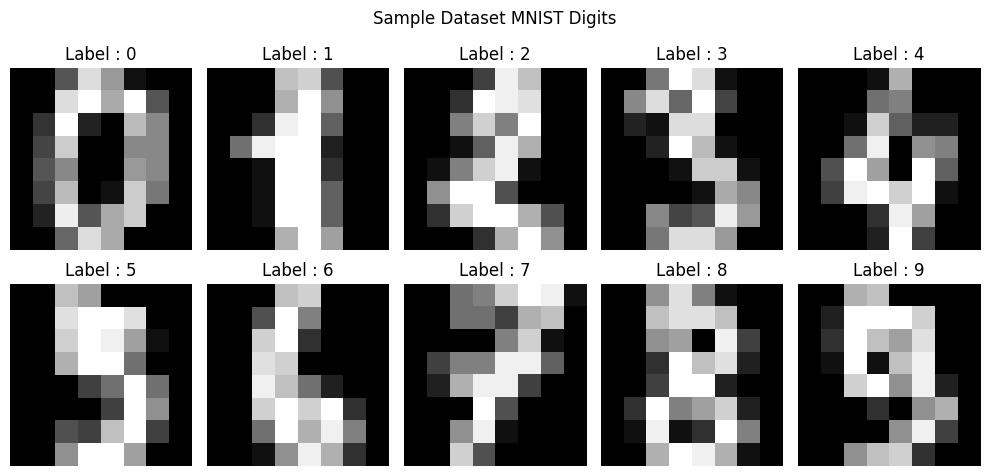

Shape Feature : (1000, 46)

KNN CLASSIFICATION
Metric=euclidean, k=1, Accuracy=0.8067
Metric=euclidean, k=3, Accuracy=0.8200
Metric=euclidean, k=5, Accuracy=0.8300
Metric=euclidean, k=7, Accuracy=0.8367
Metric=euclidean, k=9, Accuracy=0.8300
Metric=euclidean, k=11, Accuracy=0.8433
Metric=manhattan, k=1, Accuracy=0.7967
Metric=manhattan, k=3, Accuracy=0.8267
Metric=manhattan, k=5, Accuracy=0.8233
Metric=manhattan, k=7, Accuracy=0.8300
Metric=manhattan, k=9, Accuracy=0.8233
Metric=manhattan, k=11, Accuracy=0.8433
Metric=minkowski, k=1, Accuracy=0.8067
Metric=minkowski, k=3, Accuracy=0.8200
Metric=minkowski, k=5, Accuracy=0.8300
Metric=minkowski, k=7, Accuracy=0.8367
Metric=minkowski, k=9, Accuracy=0.8300
Metric=minkowski, k=11, Accuracy=0.8433
       Metric   k  Accuracy  Precision    Recall        F1  Train Time  \
0   euclidean   1  0.806667   0.801785  0.806667  0.799557    0.003668   
1   euclidean   3  0.820000   0.821838  0.820000  0.809240    0.001302   
2   euclidean   5  0.83000

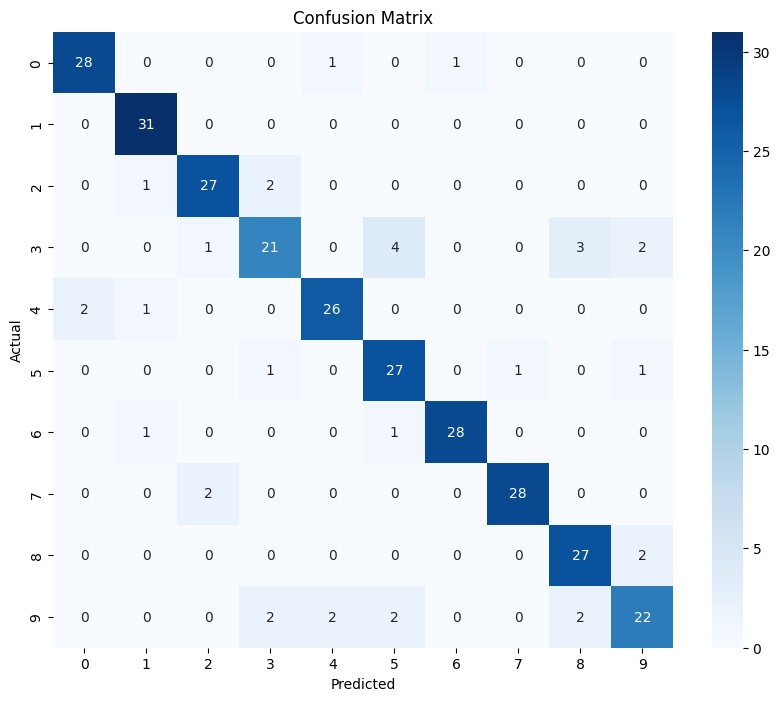

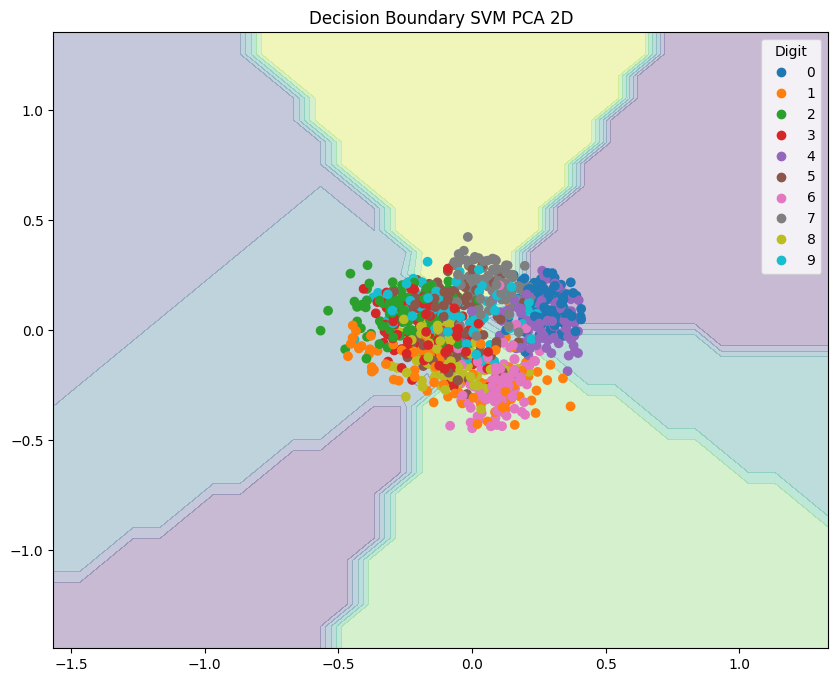

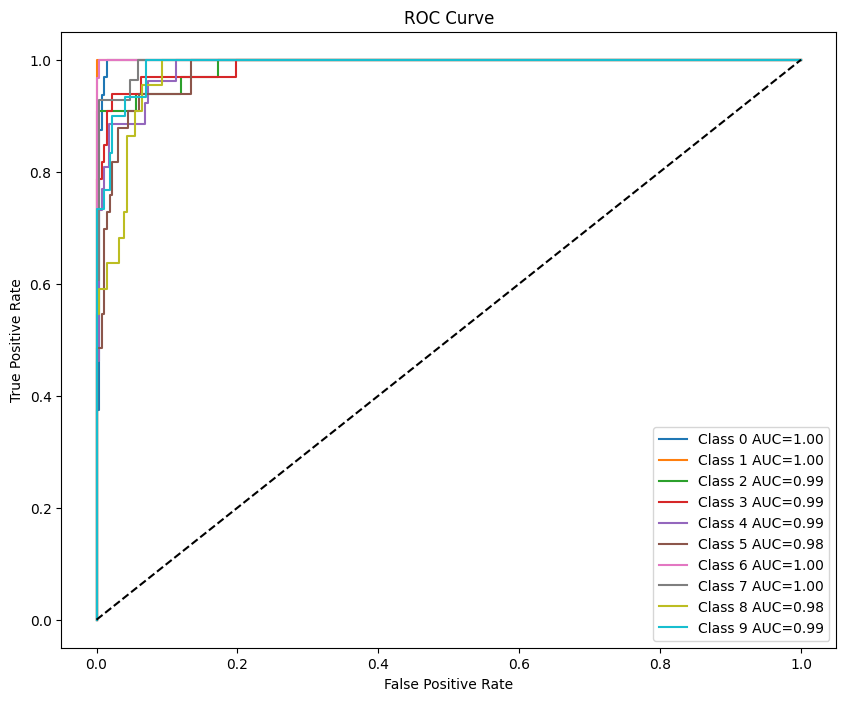


CROSS VALIDATION
CV Scores : [0.86  0.815 0.855 0.81  0.815]
Mean Accuracy : 0.8309999999999998


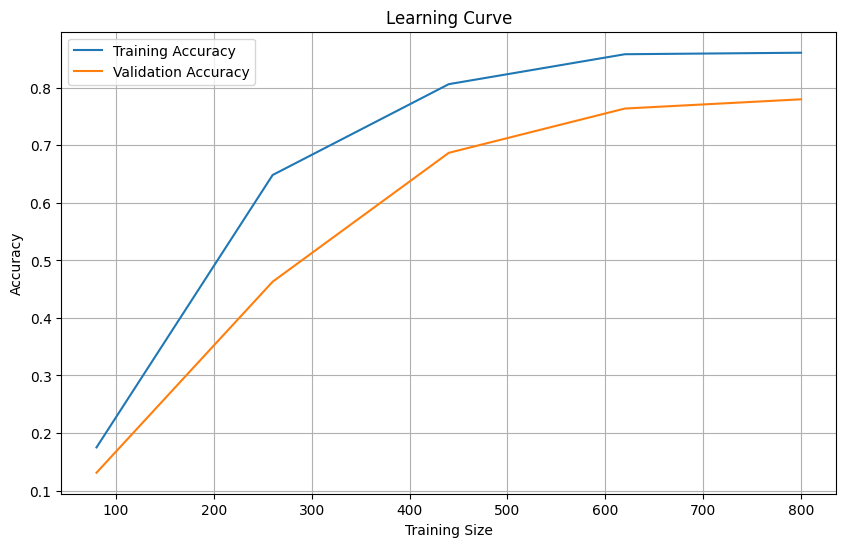


GRID SEARCH
Best Parameters : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Score : 0.8942857142857144

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.91      1.00      0.95        31
           2       0.90      0.90      0.90        30
           3       0.81      0.68      0.74        31
           4       0.90      0.90      0.90        29
           5       0.79      0.90      0.84        30
           6       0.97      0.93      0.95        30
           7       0.97      0.93      0.95        30
           8       0.84      0.93      0.89        29
           9       0.81      0.73      0.77        30

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA

from skimage.feature import hog, local_binary_pattern

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD DATASET
# ============================================================

digits = load_digits()

X_images = digits.images
y = digits.target

# Ambil 1000 sampel
X_images = X_images[:1000]
y = y[:1000]

print("Jumlah data :", len(X_images))
print("Jumlah kelas :", len(np.unique(y)))

# ============================================================
# VISUALISASI DATASET
# ============================================================

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_images[i], cmap='gray')
    ax.set_title(f"Label : {y[i]}")
    ax.axis('off')

plt.suptitle("Sample Dataset MNIST Digits")
plt.tight_layout()
plt.show()

# ============================================================
# EKSTRAKSI FITUR
# 1. HOG
# 2. LBP
# ============================================================

hog_features = []
lbp_features = []

for img in X_images:

    # -------------------------
    # HOG FEATURE
    # -------------------------

    hog_feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        visualize=False
    )

    hog_features.append(hog_feat)

    # -------------------------
    # LBP FEATURE
    # -------------------------

    lbp = local_binary_pattern(
        img,
        P=8,
        R=1,
        method='uniform'
    )

    (hist, _) = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0,10)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    lbp_features.append(hist)

hog_features = np.array(hog_features)
lbp_features = np.array(lbp_features)

# Gabungkan fitur
X = np.hstack([hog_features, lbp_features])

print("Shape Feature :", X.shape)

# ============================================================
# SPLIT DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ============================================================
# NORMALISASI
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# KNN CLASSIFICATION
# ============================================================

print("\nKNN CLASSIFICATION")
print("="*50)

k_values = [1,3,5,7,9,11]

distance_metrics = [
    'euclidean',
    'manhattan',
    'minkowski'
]

knn_results = []

for metric in distance_metrics:

    for k in k_values:

        start_train = time.time()

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train, y_train)

        train_time = time.time() - start_train

        start_test = time.time()

        y_pred = knn.predict(X_test)

        test_time = time.time() - start_test

        acc = accuracy_score(y_test, y_pred)

        prec = precision_score(
            y_test,
            y_pred,
            average='weighted'
        )

        rec = recall_score(
            y_test,
            y_pred,
            average='weighted'
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average='weighted'
        )

        knn_results.append([
            metric,
            k,
            acc,
            prec,
            rec,
            f1,
            train_time,
            test_time
        ])

        print(
            f"Metric={metric}, k={k}, Accuracy={acc:.4f}"
        )

# ============================================================
# HASIL KNN
# ============================================================

knn_df = pd.DataFrame(
    knn_results,
    columns=[
        'Metric',
        'k',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'Train Time',
        'Test Time'
    ]
)

print(knn_df)

# ============================================================
# SVM CLASSIFICATION
# ============================================================

print("\nSVM CLASSIFICATION")
print("="*50)

kernels = ['linear', 'poly', 'rbf']

C_values = [0.1, 1, 10, 100]

gamma_values = [0.001, 0.01, 0.1, 1]

svm_results = []

for kernel in kernels:

    for C in C_values:

        if kernel == 'rbf':

            for gamma in gamma_values:

                start_train = time.time()

                svm_model = SVC(
                    kernel=kernel,
                    C=C,
                    gamma=gamma
                )

                svm_model.fit(X_train, y_train)

                train_time = time.time() - start_train

                start_test = time.time()

                y_pred = svm_model.predict(X_test)

                test_time = time.time() - start_test

                acc = accuracy_score(y_test, y_pred)

                prec = precision_score(
                    y_test,
                    y_pred,
                    average='weighted'
                )

                rec = recall_score(
                    y_test,
                    y_pred,
                    average='weighted'
                )

                f1 = f1_score(
                    y_test,
                    y_pred,
                    average='weighted'
                )

                svm_results.append([
                    kernel,
                    C,
                    gamma,
                    acc,
                    prec,
                    rec,
                    f1,
                    train_time,
                    test_time
                ])

                print(
                    f"Kernel={kernel}, C={C}, gamma={gamma}, Accuracy={acc:.4f}"
                )

        else:

            start_train = time.time()

            svm_model = SVC(
                kernel=kernel,
                C=C
            )

            svm_model.fit(X_train, y_train)

            train_time = time.time() - start_train

            start_test = time.time()

            y_pred = svm_model.predict(X_test)

            test_time = time.time() - start_test

            acc = accuracy_score(y_test, y_pred)

            prec = precision_score(
                y_test,
                y_pred,
                average='weighted'
            )

            rec = recall_score(
                y_test,
                y_pred,
                average='weighted'
            )

            f1 = f1_score(
                y_test,
                y_pred,
                average='weighted'
            )

            svm_results.append([
                kernel,
                C,
                '-',
                acc,
                prec,
                rec,
                f1,
                train_time,
                test_time
            ])

            print(
                f"Kernel={kernel}, C={C}, Accuracy={acc:.4f}"
            )

# ============================================================
# HASIL SVM
# ============================================================

svm_df = pd.DataFrame(
    svm_results,
    columns=[
        'Kernel',
        'C',
        'Gamma',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'Train Time',
        'Test Time'
    ]
)

print(svm_df)

# ============================================================
# MODEL TERBAIK
# ============================================================

best_knn_idx = knn_df['Accuracy'].idxmax()
best_knn = knn_df.iloc[best_knn_idx]

best_svm_idx = svm_df['Accuracy'].idxmax()
best_svm = svm_df.iloc[best_svm_idx]

print("\nBEST KNN")
print(best_knn)

print("\nBEST SVM")
print(best_svm)

# ============================================================
# CONFUSION MATRIX
# ============================================================

best_model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01
)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# PCA DECISION BOUNDARY
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

svm_vis = SVC(kernel='rbf', C=10, gamma=0.01)

svm_vis.fit(X_train_pca, y_train_pca)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = svm_vis.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))

plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='tab10'
)

plt.legend(*scatter.legend_elements(), title="Digit")

plt.title("Decision Boundary SVM PCA 2D")
plt.show()

# ============================================================
# ROC CURVE
# ============================================================

y_bin = label_binarize(y, classes=np.unique(y))

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_bin,
    test_size=0.3,
    random_state=42
)

classifier = OneVsRestClassifier(
    SVC(
        kernel='rbf',
        probability=True
    )
)

classifier.fit(X_train_r, y_train_r)

y_score = classifier.predict_proba(X_test_r)

plt.figure(figsize=(10,8))

for i in range(10):

    fpr, tpr, _ = roc_curve(
        y_test_r[:,i],
        y_score[:,i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {i} AUC={roc_auc:.2f}"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ============================================================
# CROSS VALIDATION
# ============================================================

print("\nCROSS VALIDATION")
print("="*50)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_cv = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01
)

scores = cross_val_score(
    svm_cv,
    X,
    y,
    cv=cv
)

print("CV Scores :", scores)
print("Mean Accuracy :", scores.mean())

# ============================================================
# LEARNING CURVE
# ============================================================

train_sizes, train_scores, test_scores = learning_curve(
    svm_cv,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_mean,
    label='Validation Accuracy'
)

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# GRID SEARCH
# ============================================================

print("\nGRID SEARCH")
print("="*50)

param_grid = {
    'C':[0.1,1,10],
    'gamma':[0.001,0.01,0.1],
    'kernel':['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best Score :", grid.best_score_)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")
print("="*50)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)